# 04 · Artifacts, referencing and noise cancellation

**ROBT613 · Brain–Computer Interfaces** | Academic tutorial and independent exercises

## Goal
Detect bad channels, compare reference choices, and understand regression and ICA through a controlled contamination experiment.

**Data:** EEGBCI for QC/ICA; explicit controlled contamination for regression

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Paradigm background and experimental design

### Motor imagery and sensorimotor rhythms

Motor imagery is the internal rehearsal of movement without overt execution. In a sensorimotor-rhythm BCI, the intended action is inferred from changes in oscillatory activity, commonly within the mu and beta ranges. Event-related desynchronization denotes reduced band power relative to a reference interval; it does not mean that the EEG voltage becomes uniformly negative. The spatial and temporal distributions are variable across participants and trials.

A minimal cue-based experiment presents a fixation interval followed by a left- or right-hand instruction, an imagery interval and a rest interval. The participant imagines the kinesthetic sensation of movement while maintaining posture. An EEG cap, amplifier and acquisition computer record continuous signals; a stimulus computer records cue onset and class. Additional EOG or EMG channels, when actually acquired, can support artifact assessment. Their presence must not be assumed from scalp EEG alone.

A trial is one instructed imagery interval; a run is a sequence of trials; a session is a recording visit. These levels are not exchangeable independent samples. Run-wise evaluation assesses transfer across recording blocks, whereas subject-wise evaluation addresses a different generalization claim. Averaging signed voltages can suppress induced rhythms whose phases vary between trials; band power or time–frequency estimates are therefore central measurements.

### Acquisition provenance and instructional protocol

PhysioNet EEGBCI: 64 scalp channels, 160 Hz. Runs 4, 8 and 12 encode imagined left/right fist movement; individual lessons may use only run 4. Acquisition used BCI2000. The original database also contains executed movements and other imagery tasks.

**Acquisition reference:** [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). The sampling rate of processed epochs can differ from the original acquisition rate after explicit resampling.

| Experimental component | Required record and analytical purpose |
|---|---|
| Participant instruction | Defines the task and distinguishes attention, imagery and execution |
| Stimulus/event clock | Provides onset markers for alignment; its synchronization must be documented |
| Measurement hardware | Records sensor type, locations, reference and original sampling frequency |
| Trial, run and session log | Preserves dependence structure and supports appropriate validation |
| Quality observations | Records movement, contact failures and rejected intervals without changing labels |

**Experimental sequence:** Cue and task instruction → continuous EEG → imagery epoch → spectral/spatial features. Exact cue durations and hardware settings must be obtained from the original protocol; the analysis windows below are explicitly chosen processing intervals.

### Measurement model and interpretation

For EEG, a sensor measures a potential difference, not neuronal firing rate. The observed signal combines neural activity, physiological interference, environmental interference and measurement noise. Filtering or projection changes this mixture and cannot establish that the remaining signal is exclusively neural. For fNIRS, replace the electrical measurement model with the optical model defined below. Experimental labels are external observations; they must not be reconstructed from a classifier's predictions.

### Mathematical definitions for this lesson

In a linear artifact model $X=S+BR+E$, $X\in\mathbb R^{C\times T}$ contains measurements and $R\in\mathbb R^{Q\times T}$ reference signals. Least squares gives $\hat B=XR^\top(RR^\top)^{\dagger}$ and residual $X-\hat BR$. The pseudoinverse accommodates rank deficiency but does not ensure physiological specificity. ICA instead posits $X=AS$ and estimates an unmixing matrix $W$ using independence-related assumptions. Component removal is a substantive decision, not a consequence of decomposition alone.

Throughout, $i$ indexes trials, $c$ channels, $k$ samples, $N$ trials, $C$ channels and $T$ samples per trial unless a local definition states otherwise. An EEG epoch array has shape $(N,C,T)$; classifier features have shape $(N,d)$. A change of representation must preserve the correspondence between observations and labels.


**Methodological reading:** [Widmann, Schröger and Maess (2015). Digital filter design for electrophysiological data—a practical approach](https://doi.org/10.1016/j.jneumeth.2014.08.002). Filter response, distortion and design considerations.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Complete the analytical task in its workspace.
4. Continue to the worked solution and compare the reasoning, as well as the numerical result.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Independent exercise” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## Analytical objectives

This lesson examines the relationship between the experimental task, the measured signal and the assumptions of the analysis. Interpret each computational result in relation to the acquisition protocol and the stated evaluation design.

### Learning outcomes

- Distinguish temporal filtering, spatial referencing, rejection and nuisance regression.
- Calculate how a bad channel contaminates an average reference.
- Explain what ICA can and cannot identify from independence.
- Evaluate cleaning on data not used to fit the cleaning model.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

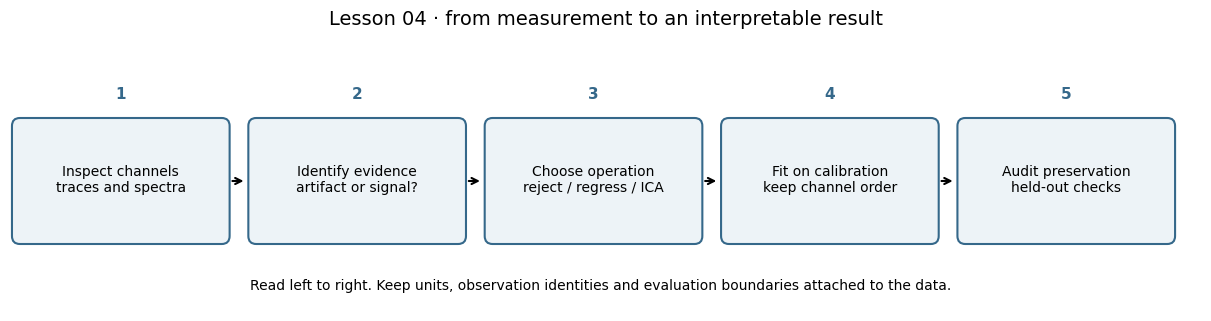

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Inspect channels\ntraces and spectra', 'Identify evidence\nartifact or signal?', 'Choose operation\nreject / regress / ICA', 'Fit on calibration\nkeep channel order', 'Audit preservation\nheld-out checks']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 04 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Inspect channels: traces and spectra → Identify evidence: artifact or signal? → Choose operation: reject / regress / ICA → Fit on calibration: keep channel order → Audit preservation: held-out checks.

## Symbols and a calculation by hand

$X$: samples × channels for regression; $E$: nuisance-reference matrix; $B$: nuisance coefficients; $R$: reference operator.

### Derive the operation before calling the library

Least squares minimizes $\|X-EB\|_F^2$. Setting its derivative to zero gives $E^TEB=E^TX$. In code, `lstsq(E, X)` solves without explicitly forming an inverse. The cleaned estimate is $X-EB$ using coefficients learned on calibration observations.

Average referencing applies $R=I-\mathbf1\mathbf1^T/C$. Since $R\mathbf1=0$, the shared constant direction disappears and rank is at most $C-1$. For sensor values $[1,2,90]$, the mean is 31 and the referenced vector is $[-30,-29,59]$. Pairwise sensor differences are preserved, yet a bad sensor contaminates the common reference.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Diagnose before correcting

EEG is a mixture of activity of interest and other electrical contributions. “Noise” is defined relative to the question: an eye movement is useful in an eye-tracking experiment but can confound a motor-imagery decoder. Large amplitude alone does not prove that a component is non-neural. Start with channel names/types, time traces, spectra and the relation to task events. Ask whether the anomaly is confined to one sensor, one interval or a recurring pattern across channels.

| Observation | Candidate explanation | First investigation |
|---|---|---|
| One almost constant channel | Poor contact or disconnected lead | Trace and channel variance |
| Sharp narrow spectral peak | Mains interference | PSD and local mains frequency |
| Large frontal slow waves | Blinks or eye motion | Frontal traces and measured EOG if available |
| High-frequency bursts | Muscle activity or movement | Time-frequency distribution and task timing |
| Abrupt shared step | Movement or recording discontinuity | Annotations and acquisition notes |

A candidate explanation is not a diagnosis. A preprocessing record should state the evidence, decision and quantity removed. Filtering attenuates frequencies; it cannot separate two signals in the same band. Rejection removes observations. Regression subtracts the part predictable from measured nuisance channels. ICA changes the coordinate system so that a recurring mixture can sometimes be isolated more clearly.

### Referencing is a linear transformation

For a column vector of $C$ channel measurements, common-average referencing is $x_r=Rx$ with

$$R=I-\frac{1}{C}\mathbf1\mathbf1^T.$$

The channels sum to zero afterward, so one degree of freedom is lost. This is expected, not a software failure. If one channel has a large artifact, subtracting its contribution to the average spreads that artifact into all other channels. Inspect and mark bad sensors before choosing the reference. Scalp topographies are sensor-level summaries; this course does not infer anatomical generators.

### Regression and ICA require assumptions

The least-squares nuisance model $X=EB+U$ assumes that a stable linear combination of nuisance measurements explains contamination. If $E$ contains task-related brain activity, the same subtraction can remove the response we want. Low residual variance is therefore insufficient evidence of successful cleaning. Use a controlled mixture when you need ground truth, and inspect task-related changes when processing real recordings.

ICA instead seeks statistically independent component time courses. Its component numbering, signs and scales are arbitrary. Evidence such as a frontal map, blink-shaped time course and correlation with a genuine EOG channel supports an ocular interpretation. None of these should be replaced with a rule such as “remove component zero.” The example below deliberately leaves exclusions empty because this recording has no dedicated EOG channel. Students practice building an evidence record rather than accepting an automatic label.

## Visual intuition · See how a shared reference spreads contamination

**Independent exercise:** The first two sensors are quiet. Predict their referenced amplitudes when a third sensor has a large offset.

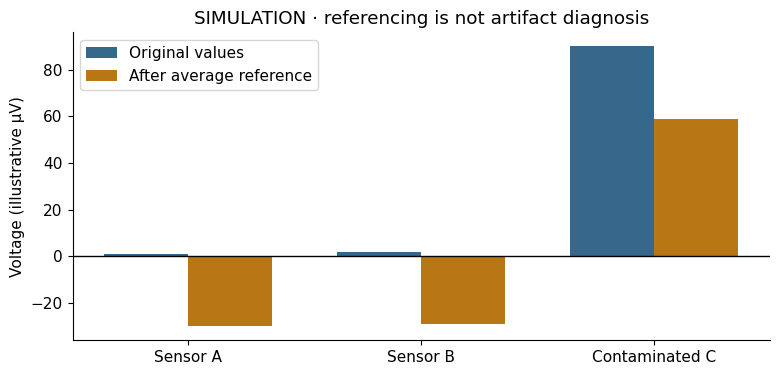

In [3]:
vis_before=np.array([1.,2.,90.]);vis_after=vis_before-vis_before.mean()
fig,ax=plt.subplots(figsize=(9,4));vis_idx=np.arange(3)
ax.bar(vis_idx-.18,vis_before,.36,label='Original values',color='#35688a')
ax.bar(vis_idx+.18,vis_after,.36,label='After average reference',color='#b87714')
ax.axhline(0,color='black',lw=1)
ax.set(xticks=vis_idx,xticklabels=['Sensor A','Sensor B','Contaminated C'],ylabel='Voltage (illustrative µV)',title='SIMULATION · referencing is not artifact diagnosis')
ax.legend();plt.show()

### Worked interpretation

The contaminated channel shifts both quiet sensors downward. Their difference remains 1 µV, but neither stays near zero. Inspect bad channels before computing a common reference; a zero across-channel mean is not a cleanliness test.

## Guided practice 1 · a bad sensor changes every reference

Predict the mean of each time column before running. The third sensor has an artificial offset; inspect how subtracting the average affects the two initially quiet sensors.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
demo_channels=np.array([[1.,2.,1.],[2.,1.,2.],[90.,90.,90.]])
demo_ref=demo_channels-demo_channels.mean(axis=0,keepdims=True)
print('Before:\n',demo_channels,'\nAverage referenced:\n',demo_ref)
assert np.allclose(demo_ref.mean(axis=0),0)

Before:
 [[ 1.  2.  1.]
 [ 2.  1.  2.]
 [90. 90. 90.]] 
Average referenced:
 [[-30. -29. -30.]
 [-29. -30. -29.]
 [ 59.  59.  59.]]


### Why this result makes sense

A zero channel average is a mathematical property, not evidence that the recording is clean. The contaminated channel changes the reference for every channel.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · rank after average reference

Construct the reference matrix explicitly. Compare its rank with the number of channels and apply it twice.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_C=4
demo_R=np.eye(demo_C)-np.ones((demo_C,demo_C))/demo_C
print('Rank:',np.linalg.matrix_rank(demo_R),'of',demo_C)
assert np.allclose(demo_R@demo_R,demo_R)

Rank: 3 of 4


### Why this result makes sense

The second application changes nothing: this is a projection. Covariance-based methods must account for the resulting rank.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · regression can remove wanted signal

Let a nuisance reference contain a component perfectly correlated with a desired oscillation. Even though subtraction reduces variance, examine its effect on the desired oscillation.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_t=np.arange(1280)/128
demo_wanted=np.sin(2*np.pi*10*demo_t)
demo_nuisance=demo_wanted+.3*np.sin(2*np.pi*2*demo_t)
demo_observed=demo_wanted+.5*demo_nuisance
demo_b=np.linalg.lstsq(demo_nuisance[:,None],demo_observed,rcond=None)[0]
demo_residual=demo_observed-demo_nuisance*demo_b[0]
print('Variance before / after:',np.var(demo_observed),np.var(demo_residual))
print('Wanted-wave coefficient before / after:',np.dot(demo_observed,demo_wanted)/np.dot(demo_wanted,demo_wanted),np.dot(demo_residual,demo_wanted)/np.dot(demo_wanted,demo_wanted))

Variance before / after: 1.13625 0.041284403669724766
Wanted-wave coefficient before / after: 1.5 0.08256880733944942


### Why this result makes sense

The desired coefficient should be one in the uncontaminated signal. A much smaller residual coefficient shows why minimizing amplitude is the wrong objective.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · correlation is not identity

A mixture can correlate strongly with an artifact reference and still contain useful activity. Calculate the association and describe what extra evidence would be needed before removal.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_reference=np.linspace(-1,1,100)
demo_useful=np.sin(np.linspace(0,8*np.pi,100))
demo_mixture=3*demo_reference+demo_useful
print('Reference correlation:',np.corrcoef(demo_mixture,demo_reference)[0,1])
print('Useful activity variance:',np.var(demo_useful))

Reference correlation: 0.9194681575780782
Useful activity variance: 0.495


### Why this result makes sense

Correlation measures association. It neither labels every sample as artifact nor guarantees that all useful variance is preserved by subtraction.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Implement the reference

Implement average_reference for a channel × time array without modifying the input.

**Independent exercise:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def average_reference(values):
    # TODO: channel axis is zero; preserve input.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def average_reference(values):
    return values-values.mean(axis=0,keepdims=True)

In [10]:
answer=average_reference(demo_channels)
if answer is not None:
    assert answer.shape==demo_channels.shape
    assert np.allclose(answer.mean(axis=0),0)
    assert np.allclose(answer[0]-answer[1],demo_channels[0]-demo_channels[1])
    print('Reference checks passed.')
else: print('Exercise pending: implement average_reference.')

Reference checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

Common-average reference subtracts $\bar x(t)=C^{-1}\sum_c x_c(t)$ from each EEG channel. It reduces rank by one and assumes the sampled scalp average is useful. A bad channel can contaminate all channels, so inspect channels first. Marking, interpolation and rejection are distinct decisions; never interpolate most of a sparse montage and call it recovered neural data.

For an observed EEG matrix $X$ and nuisance reference $E$, least squares estimates $B=(E^TE)^{-1}E^TX$ and forms $X_{clean}=X-EB$. It removes all activity correlated with the reference, including genuine neural signal. Fit nuisance coefficients on calibration data only, then apply them unchanged to evaluation data.

ICA assumes $X=AS$, with approximately independent sources $S$. It estimates an unmixing matrix $W$ and removes selected source contributions before reconstruction. Independence is statistical, not a label saying “artifact.” Inspect scalp maps, time courses, spectra and EOG/ECG association. Fit ICA on a high-pass-filtered copy (commonly 1 Hz) and apply its spatial solution to compatible data with the same channels/reference. Do not remove components solely because their variance is large.

## Inspect real channel quality
EEGBCI has EEG channels but no dedicated EOG channel. We do not invent an EOG sensor or automatically remove an arbitrary ICA component.

The channel table ranks variation and extreme excursions as screening aids. Neither column is an automatic bad-channel label. EEGBCI lacks dedicated EOG here, so channel-type inspection prevents us from pretending an ocular reference was measured.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Fetch only the specified participant/run files; the cache prevents repeat downloads.

**3.** Read continuous voltage samples and metadata into an MNE Raw object.

**4.** Standardize dataset channel names so later sensor-name selection is meaningful.

**5.** Attach sensor coordinates; this does not perform anatomical source localization.

**6.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**7.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [11]:
# Import the named tools used in this step.
from mne.datasets import eegbci
# Fetch only the specified participant/run files; the cache prevents repeat downloads.
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
# Read continuous voltage samples and metadata into an MNE Raw object.
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
# Standardize dataset channel names so later sensor-name selection is meaningful.
eegbci.standardize(raw)
# Attach sensor coordinates; this does not perform anatomical source localization.
raw.set_montage('standard_1005')
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(raw)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Channel types:', set(raw.get_channel_types()))

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


/tmp/ipykernel_476500/1909471534.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


### Step 1.2 · trace the next operation

**1.** Expose the numerical array; EEG values are in volts and the final axis is time.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

   channel     std_uV  peak_to_peak_uV
21     Fp1  83.055518            971.0
23     Fp2  74.355221            880.0
24     AF7  79.132063            879.0
25     AF3  76.883206            859.0
22     Fpz  69.775310            821.0
28     AF8  65.841139            802.0
29      F7  64.143214            654.0
30      F5  67.379299            641.0
26     AFz  56.546076            573.0
27     AF4  55.186773            572.0


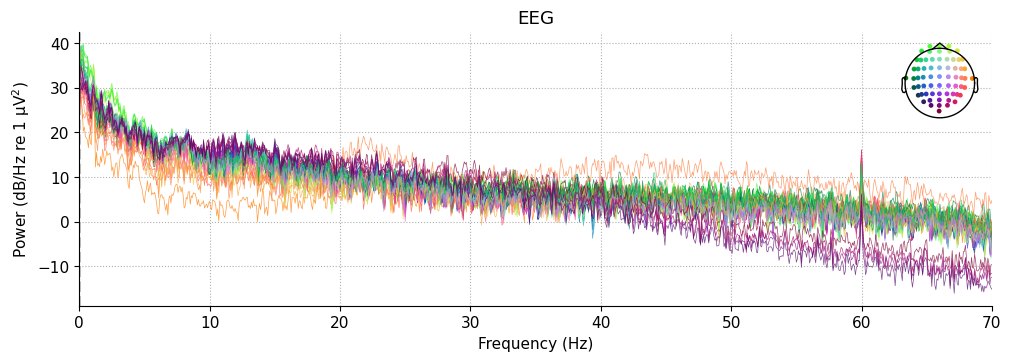

In [12]:
# Expose the numerical array; EEG values are in volts and the final axis is time.
values = raw.get_data()
# Store this intermediate result so the next operation can be traced and inspected.
quality = pd.DataFrame({'channel': raw.ch_names, 'std_uV': values.std(1) * 1000000.0, 'peak_to_peak_uV': np.ptp(values, axis=1) * 1000000.0})
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(quality.sort_values('peak_to_peak_uV', ascending=False).head(10))
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
raw.copy().compute_psd(fmax=70).plot(show=False)
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Select a suspicious channel and inspect its waveform and spectrum before making a decision. Note whether the issue is sustained, intermittent or shared across sensors.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · Inspect the most extreme channel rather than deleting it

**Independent exercise:** Plot the first five seconds of the channel with the largest peak-to-peak amplitude. State what this short view can and cannot establish.

**My reasoning / hand calculation:** _write here._

In [13]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

The largest range is a screening flag; it is not an artifact diagnosis.

### Worked solution

Run the following calculation after attempting your own version.

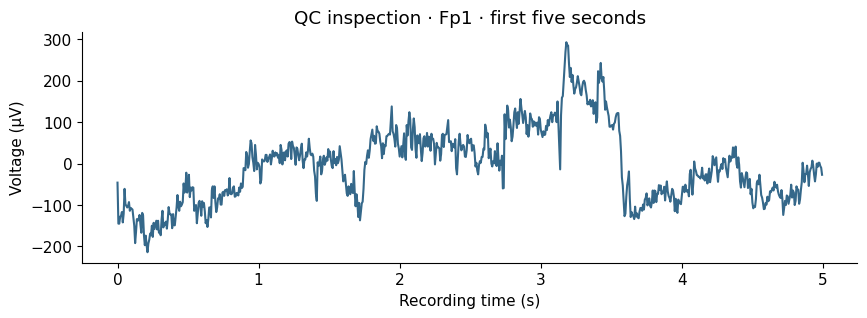

In [14]:
lab_channel=quality.loc[quality.peak_to_peak_uV.idxmax(),'channel']
lab_trace=raw.get_data(picks=[lab_channel])[0]
lab_n=min(len(lab_trace),int(5*raw.info['sfreq']))
fig,ax=plt.subplots(figsize=(10,3))
ax.plot(raw.times[:lab_n],lab_trace[:lab_n]*1e6,color='#35688a')
ax.set(xlabel='Recording time (s)',ylabel='Voltage (µV)',title=f'QC inspection · {lab_channel} · first five seconds')
plt.show()

### Interpret and check

This view shows whether the beginning contains a flat trace, clipping or obvious excursions. The largest artifact may occur later, so a quiet five-second window does not clear the whole channel. Inspect the full interval and compare neighboring sensors before marking a bad channel.

## Controlled reference regression
Here clean signal and blink reference are known by construction. Calibration is the first half and evaluation the second half; the simulation is not a claim of clinical artifact removal.

The controlled mixture supplies known ground truth, making an RMSE comparison meaningful. Only the first half fits the nuisance coefficient; the second half assesses whether that coefficient transfers. This is a calibration/evaluation separation for preprocessing itself.

### Step 2.1 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Store this intermediate result so the next operation can be traced and inspected.

**3.** Store this intermediate result so the next operation can be traced and inspected.

**4.** Store this intermediate result so the next operation can be traced and inspected.

**5.** Store this intermediate result so the next operation can be traced and inspected.

**6.** Store this intermediate result so the next operation can be traced and inspected.

**7.** Estimate nuisance coefficients from calibration observations by least squares.

In [15]:
# Store this intermediate result so the next operation can be traced and inspected.
fs = 128
# Store this intermediate result so the next operation can be traced and inspected.
t = np.arange(fs * 40) / fs
# Store this intermediate result so the next operation can be traced and inspected.
clean = 8e-06 * np.sin(2 * np.pi * 10 * t) + rng.normal(0, 2e-06, len(t))
# Store this intermediate result so the next operation can be traced and inspected.
eog = sum((0.0001 * np.exp(-0.5 * ((t - center) / 0.12) ** 2) for center in range(2, 39, 3)))
# Store this intermediate result so the next operation can be traced and inspected.
observed = clean + 0.7 * eog
# Store this intermediate result so the next operation can be traced and inspected.
cal = t < 20
# Estimate nuisance coefficients from calibration observations by least squares.
B = np.linalg.lstsq(eog[cal, None], observed[cal], rcond=None)[0]

### Step 2.2 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [16]:
# Store this intermediate result so the next operation can be traced and inspected.
corrected = observed - eog * B[0]
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Held-out RMSE before / after (µV):', np.sqrt(np.mean((observed[~cal] - clean[~cal]) ** 2)) * 1000000.0, np.sqrt(np.mean((corrected[~cal] - clean[~cal]) ** 2)) * 1000000.0)

Held-out RMSE before / after (µV): 18.430218722468922 0.032864897844679136


### Step 2.3 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Plot each named condition on comparable axes without changing its observations.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

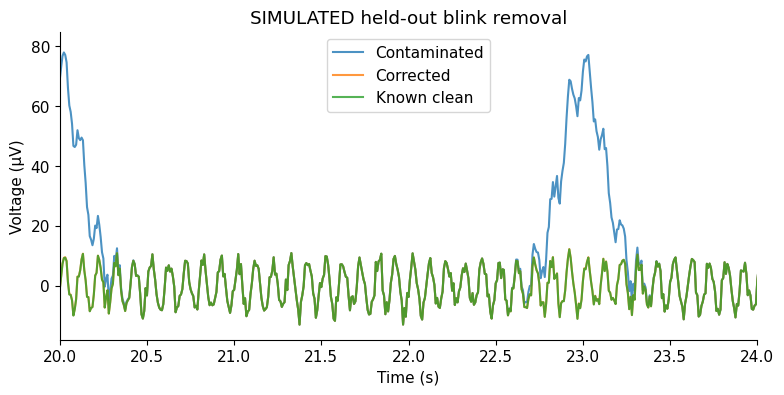

In [17]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Plot each named condition on comparable axes without changing its observations.
for z, name in [(observed, 'Contaminated'), (corrected, 'Corrected'), (clean, 'Known clean')]:
    ax.plot(t, z * 1000000.0, label=name, alpha=0.8)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(xlim=(20, 24), xlabel='Time (s)', ylabel='Voltage (µV)', title='SIMULATED held-out blink removal')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Compare corrected and known-clean traces on the held-out interval. If you change the nuisance relationship after calibration, predict the direction of failure before rerunning.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Break the regression stationarity assumption

**Independent exercise:** Keep calibration contamination at 0.7 times EOG but change evaluation contamination to 1.2. Apply the original coefficient and calculate residual error.

**My reasoning / hand calculation:** _write here._

In [18]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Do not refit after changing the evaluation interval.

### Worked solution

Run the following calculation after attempting your own version.

In [19]:
lab_changed=clean+np.where(cal,.7,1.2)*eog
lab_corrected=lab_changed-eog*B[0]
lab_rmse=np.sqrt(np.mean((lab_corrected[~cal]-clean[~cal])**2))*1e6
print('Original fitted coefficient:',B[0])
print('Held-out RMSE after coupling changes (µV):',lab_rmse)

Original fitted coefficient: 0.6987517549933778
Held-out RMSE after coupling changes (µV): 13.19730684246534


### Interpret and check

The calibration coefficient no longer matches evaluation coupling. Residual contamination increases even though the regression code is unchanged. Ground truth is known only because this is a controlled mixture; on real EEG, low residual amplitude alone would not prove successful cleaning.

## Fit ICA and inspect, without automatic exclusion
This demonstration uses a calibration segment only. Set exclusions only after reviewing evidence; the default removes nothing.

ICA is fitted on a filtered calibration segment. The spatial decomposition can then be inspected, but exclusions remain empty until evidence supports a decision. This avoids teaching component index as an artifact label.

### Step 3.1 · trace the next operation

**1.** Apply the declared frequency filter; copy first when the original must be preserved.

**2.** Configure a reproducible statistical decomposition; component identity is not an artifact label.

**3.** Learn the spatial decomposition from the calibration segment only.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Render the completed figure and inspect labels, units and the comparison.

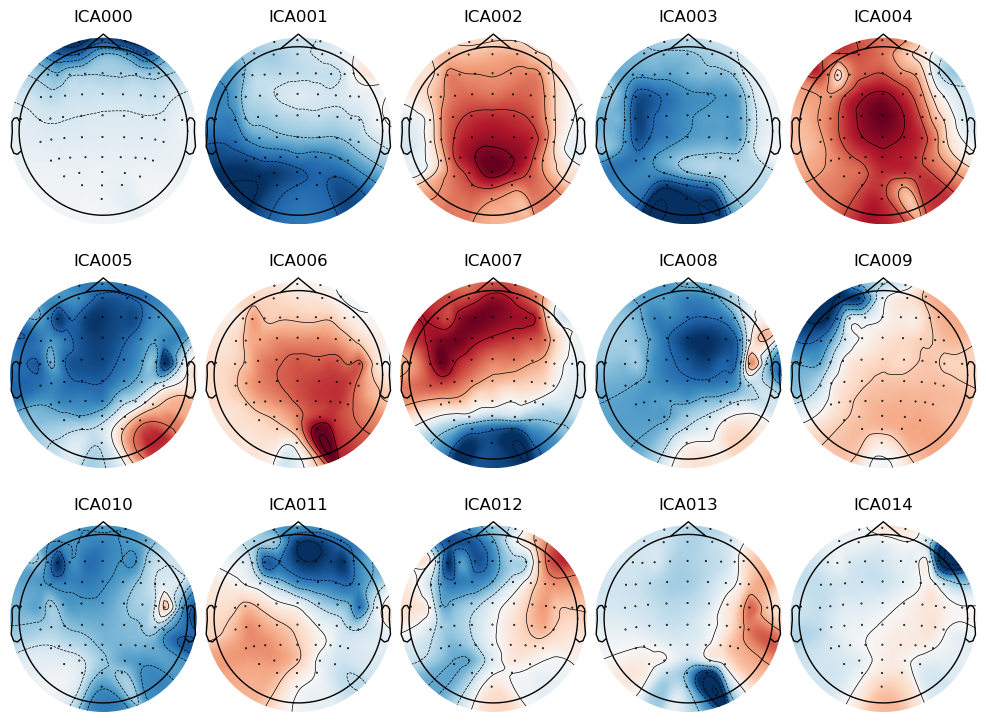

In [20]:
# Apply the declared frequency filter; copy first when the original must be preserved.
calibration = raw.copy().crop(tmin=0, tmax=min(60, raw.times[-1])).filter(1, 40)
# Configure a reproducible statistical decomposition; component identity is not an artifact label.
ica = mne.preprocessing.ICA(n_components=15, method='fastica', random_state=SEED, max_iter=1000)
# Learn the spatial decomposition from the calibration segment only.
ica.fit(calibration, picks='eeg', decim=3)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ica.plot_components(show=False)
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Step 3.2 · trace the next operation

**1.** Keep exclusions explicit; an empty list removes no chosen component.

**2.** Apply the fitted spatial solution to a compatible copy of the recording.

**3.** Keep exclusions explicit; an empty list removes no chosen component.

In [21]:
# Keep exclusions explicit; an empty list removes no chosen component.
ica.exclude = []
# Apply the fitted spatial solution to a compatible copy of the recording.
reconstructed = ica.apply(raw.copy())
# Keep exclusions explicit; an empty list removes no chosen component.
print('Excluded components:', ica.exclude)

Excluded components: []


### Inspect and interpret

Record the component evidence you would request: sensor map, time course, spectrum and genuine nuisance-channel association if available. An empty exclusion list means the applied reconstruction removes no chosen component.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 4 · Build an ICA evidence decision

**Independent exercise:** What evidence would justify removing a component, and what does the current empty exclusion list mean?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

Statistical independence does not assign a biological label.

### Worked solution

Seek convergent evidence: sensor distribution, time course, spectrum and association with a measured EOG/ECG channel when present. A frontal map alone is insufficient. The empty exclusion list removes no selected component; the exercise intentionally avoids inventing an EOG sensor or assuming component zero is a blink.

## Practice 5 · Compare rejection with subtraction

**Independent exercise:** How do rejecting a trial and subtracting a component affect the dataset differently?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

One changes the sample of observations; the other changes every affected waveform.

### Worked solution

Trial rejection reduces the number of observations and can alter class balance or representativeness. Component subtraction retains trials but changes their signals and may remove wanted activity. Both need a documented criterion and a before/after audit appropriate to the downstream task.

## Recorded-signal inspection with MNE-Python

The following visualization uses the recording analysed in this notebook. The API retains channel names, sample timing and physical units. This is descriptive inspection; it does not authorize selecting parameters on held-out labels.

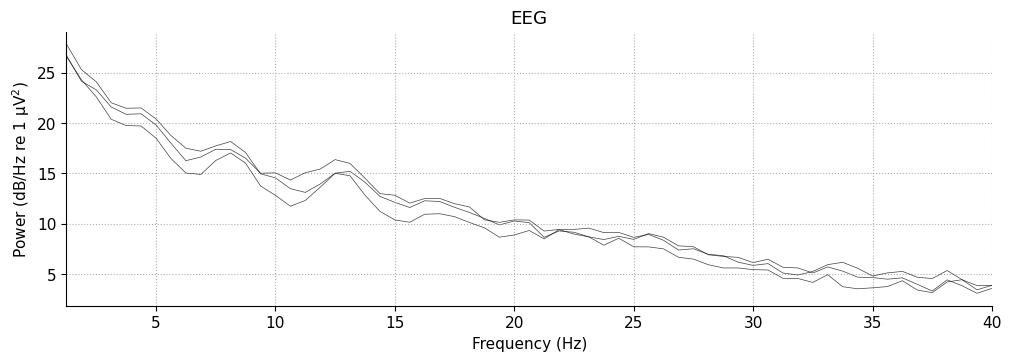

In [22]:
# Estimate the spectrum from the recorded EEG, retaining MNE metadata.
recorded_spectrum = raw.compute_psd(method='welch', fmin=1, fmax=40, picks=['C3', 'Cz', 'C4'], n_fft=256, verbose=False)
recorded_spectrum.plot(average=False, spatial_colors=False, show=False)
plt.show()

### Figure interpretation and independent exercise

The horizontal axis represents frequency; the vertical axis represents spectral density on the scale indicated by MNE. Compare central channels and identify broad-band versus narrow-band structure. A spectral difference alone does not establish task discrimination. This panel uses recorded EEG; controlled examples elsewhere remain explicitly synthetic.

**Exercise.** Identify the measurement unit, the observation represented by each trace or image row, and one conclusion that the figure cannot support. Explain how the answer changes if the signal has already been filtered.

**Reference interpretation.** The displayed observations are processed sensor measurements, not independent participants. Filtering changes the measured bandwidth and temporal structure. The plot supports quality assessment and descriptive comparisons; it does not establish causal neural mechanisms, source location or out-of-sample classification performance.

## Practice 6 · explain the complete method

Independently explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

Artifact handling begins with evidence. Referencing changes the measurement basis; rejection changes retained observations; regression and ICA subtract estimated contributions that may include wanted signal. Lower amplitude alone is not proof of better data.

## If your result is different

If correction removes the task response, investigate correlation between nuisance reference and wanted activity. If ICA is unstable, inspect bad channels, rank and calibration duration before excluding components.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[MNE ICA tutorial](https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html) · [EEG reference](https://mne.tools/stable/auto_tutorials/preprocessing/55_setting_eeg_reference.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.

## References and further reading

1. [Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python](https://doi.org/10.3389/fnins.2013.00267). Core data structures and reproducible electrophysiological analysis.
2. [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). Acquisition provenance, task definition and dataset-specific interpretation.
3. [MNE-Python API reference](https://mne.tools/stable/python_reference.html). Consult the documented units, defaults and return values of each method.
4. [MNE overview tutorial](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Relationship between continuous data, epochs and evoked responses.
5. [MNE documentation on in-place modification](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html). Object copying and preservation of analysis branches.

These references support the acquisition and software descriptions. Numerical outcomes in this notebook refer only to the explicitly selected data and evaluation design; they are not population performance estimates. Dataset terms remain separate from the licence of these teaching materials.


### Primary methodological literature

- [Widmann, Schröger and Maess (2015). Digital filter design for electrophysiological data—a practical approach](https://doi.org/10.1016/j.jneumeth.2014.08.002). Filter response, distortion and design considerations.